# YOLO11-S + 2×CBAM (P4 + P5)
**Architecture:** CBAM at P4 output (256ch) and P5 output (512ch) — neck-only attention, no backbone CBAM, no AG gates  
**Ablation context:** Tests neck-only CBAM at P4+P5 (vs 3×neck which included P3). Isolates contribution of P4+P5 suppression without P3 recall risk.  
**Goal:** Early smoke/fire detection — minimize PyroNear FP rate while preserving recall  
**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified ~55,698 images  
**Weight init:** Cold start from factory `yolo11s.pt` — no local checkpoint transfer


---
## 1. Setup

In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.7 MB/s eta 0:00:00
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


---
## 2. D-Fire — Load, Filter & Verify

In [2]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")

D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [3]:
def is_distant_shot(label_path, max_box_area=0.40):
    lbl = Path(label_path)
    if not lbl.exists():
        return True
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True

print("Filtering D-Fire (max box area = 40%)...")
dfire_kept = {}
for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split] = kept
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)


---
## 3. NEMO — Convert COCO JSON → YOLO

In [4]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"

def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")

print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")
print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")
print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images


---
## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

In [5]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099


In [6]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)

def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")

print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")

Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


---
## 5. Merge → Unified YOLO Dataset

In [7]:
UNIFIED = "/kaggle/working/unified_dataset"
for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | {pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images


---
## 6. Data YAML + Integrity Check

In [8]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)

# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [9]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    if imgs - lbls: print(f"    ⚠️  Images w/o label: {len(imgs - lbls)}")
    if lbls - imgs: print(f"    ⚠️  Labels w/o image: {len(lbls - imgs)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")

── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


---
## 7. Module Definitions

| Module | Insertion | Channels | Role |
|--------|-----------|----------|------|
| `CBAM` P4 | L20 | 256ch | Spatial+channel refinement at P4 output |
| `CBAM` P5 | L24 | 512ch | Spatial+channel refinement at P5 output |


In [10]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        mx  = self.mlp(self.max_pool(x))
        return x * self.sigmoid(avg + mx)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x


# ── Sanity checks ─────────────────────────────────────────────────────────────
for label, ch in [("P4", 256), ("P5", 512)]:
    _x    = torch.randn(2, ch, 20, 20)
    _cbam = CBAM(ch)
    _out  = _cbam(_x)
    assert _out.shape == _x.shape
    params = sum(p.numel() for p in _cbam.parameters())
    print(f"CBAM {label} {ch}ch | {tuple(_x.shape)} → {tuple(_out.shape)} | params {params:,} ✅")


CBAM P4 256ch | (2, 256, 20, 20) → (2, 256, 20, 20) | params 8,290 ✅
CBAM P5 512ch | (2, 512, 20, 20) → (2, 512, 20, 20) | params 32,866 ✅


---
## 8. Register Custom Modules into Ultralytics Runtime

In [11]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

_CUSTOM = {
    'CBAM':             CBAM,
    'ChannelAttention': ChannelAttention,
    'SpatialAttention': SpatialAttention,
}

for name, cls in _CUSTOM.items():
    tasks_mod.__dict__[name] = cls
    ulm.__dict__[name]       = cls
    conv_mod.__dict__[name]  = cls

print("All custom modules registered:")
for name in _CUSTOM:
    print(f"  tasks_mod.{name} → {tasks_mod.__dict__[name]}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All custom modules registered:
  tasks_mod.CBAM → <class '__main__.CBAM'>
  tasks_mod.ChannelAttention → <class '__main__.ChannelAttention'>
  tasks_mod.SpatialAttention → <class '__main__.SpatialAttention'>


---
## 9. YAML — YOLO11-S + 2×CBAM (P4 + P5)

### Layer index arithmetic — 2 insertions, max +2 shift vs vanilla

```
Vanilla            New (2×CBAM P4+P5)          Shift   Insertion
──────────────────────────────────────────────────────────────────
L0–L19  unchanged  L0–L19  unchanged             +0
L20  Conv s2       NEW L20  CBAM [256ch]          —      CBAM P4
                   L21  Conv s2                   +1
L21  Concat        L22  Concat([-1,10])           +1
L22  C3k2 P5       L23  C3k2 P5 (512ch)          +1     ← raw P5
                   NEW L24  CBAM [512ch]          —      CBAM P5
Detect([16,19,22]) → Detect([16, 20, 24])         —      reads CBAM outputs
```

No SPPF CBAM, no AG gates, no P3 CBAM.
Detect reads: P3 C3k2 [L16] | P4 CBAM [L20] | P5 CBAM [L24]


In [12]:
cbam_p4p5_yaml = """
# YOLO11-S + 2×CBAM (P4 + P5)
# CBAM: Woo et al., ECCV 2018 (https://arxiv.org/abs/1807.06521)
#
# Insertion points (gw=0.50):
#   L20 — CBAM [256ch]  after P4 C3k2 output
#   L24 — CBAM [512ch]  after P5 C3k2 output
#
# No SPPF CBAM, no AG gates, no P3 CBAM.
# Detect reads [16, 20, 24]

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]            # 0   P1/2
  - [-1, 1, Conv,  [128, 3, 2]]           # 1   P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]    # 2
  - [-1, 1, Conv,  [256, 3, 2]]           # 3   P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]    # 4   P3 skip (256ch)
  - [-1, 1, Conv,  [512, 3, 2]]           # 5   P4/16
  - [-1, 2, C3k2,  [512, True]]           # 6   P4 skip (256ch)
  - [-1, 1, Conv,  [1024, 3, 2]]          # 7   P5/32
  - [-1, 2, C3k2,  [1024, True]]          # 8
  - [-1, 1, SPPF,  [1024, 5]]             # 9
  - [-1, 2, C2PSA, [1024]]                # 10  (512ch)

head:
  - [-1,       1, nn.Upsample, [None, 2, nearest]]   # 11  upsample C2PSA
  - [[-1, 6],  1, Concat,      [1]]                  # 12  cat P4 skip → 768ch
  - [-1,       2, C3k2,        [512, False]]          # 13  256ch (P4 neck features)

  - [-1,       1, nn.Upsample, [None, 2, nearest]]   # 14  upsample L13
  - [[-1, 4],  1, Concat,      [1]]                  # 15  cat P3 skip → 512ch
  - [-1,       2, C3k2,        [256, False]]          # 16  128ch (P3 output — no CBAM)

  - [-1,       1, Conv,        [256, 3, 2]]           # 17  stride-2
  - [[-1, 13], 1, Concat,      [1]]                   # 18  cat neck-P4 → 384ch
  - [-1,       2, C3k2,        [512, False]]           # 19  256ch (P4 output)
  - [-1,       1, CBAM,        [256]]                  # 20  ← P4 CBAM (NEW)

  - [-1,       1, Conv,        [512, 3, 2]]            # 21  stride-2
  - [[-1, 10], 1, Concat,      [1]]                    # 22  cat C2PSA → 768ch
  - [-1,       2, C3k2,        [1024, True]]            # 23  512ch (P5 output)
  - [-1,       1, CBAM,        [512]]                   # 24  ← P5 CBAM (NEW)

  - [[16, 20, 24], 1, Detect, [nc]]                    # 25
"""

with open("/kaggle/working/yolo11s_2cbam_p4p5.yaml", "w") as f:
    f.write(cbam_p4p5_yaml.strip())
print("yolo11s_2cbam_p4p5.yaml written ✅")

from ultralytics import YOLO
test_model = YOLO("/kaggle/working/yolo11s_2cbam_p4p5.yaml")
cbam_count = 0
labels = ["P4", "P5"]
print("\nLayer index | Type")
print("-" * 35)
for i, layer in enumerate(test_model.model.model):
    is_cbam = type(layer).__name__ == 'CBAM'
    marker  = f" ← CBAM ({labels[cbam_count]})" if is_cbam else ""
    if is_cbam: cbam_count += 1
    print(f"  [{i:2d}]  {type(layer).__name__}{marker}")
assert cbam_count == 2, f"Expected 2 CBAM modules, found {cbam_count}"
print(f"\n✅ {cbam_count} CBAM modules confirmed at [L20 P4 256ch, L24 P5 512ch]")
del test_model


yolo11s_2cbam_p4p5.yaml written ✅

Layer index | Type
-----------------------------------
  [ 0]  Conv
  [ 1]  Conv
  [ 2]  C3k2
  [ 3]  Conv
  [ 4]  C3k2
  [ 5]  Conv
  [ 6]  C3k2
  [ 7]  Conv
  [ 8]  C3k2
  [ 9]  SPPF
  [10]  C2PSA
  [11]  Upsample
  [12]  Concat
  [13]  C3k2
  [14]  Upsample
  [15]  Concat
  [16]  C3k2
  [17]  Conv
  [18]  Concat
  [19]  C3k2
  [20]  CBAM ← CBAM (P4)
  [21]  Conv
  [22]  Concat
  [23]  C3k2
  [24]  CBAM ← CBAM (P5)
  [25]  Detect

✅ 2 CBAM modules confirmed at [L20 P4 256ch, L24 P5 512ch]


---
## 9b. Architecture Verification

In [13]:
from ultralytics import YOLO

print("=" * 65)
print("ARCHITECTURE VERIFICATION — YOLO11-S + 2×CBAM (P4 + P5)")
print("=" * 65)

verify_model = YOLO("/kaggle/working/yolo11s_2cbam_p4p5.yaml")
layers = list(verify_model.model.model)

NEW = {20: "CBAM P4", 24: "CBAM P5"}
print("\nLayer table:")
print(f"  {'Idx':>4}  {'Type':<28}  {'Note'}")
print(f"  {'-'*58}")
for i, layer in enumerate(layers):
    note = f"← {NEW[i]} (NEW)" if i in NEW else ""
    print(f"  [{i:>2d}]  {type(layer).__name__:<28}  {note}")

# 1. CBAM P4 @ L20
print("\n[1] CBAM P4 @ L20")
cbam_p4 = layers[20]
assert type(cbam_p4).__name__ == "CBAM"
actual  = cbam_p4.ca.mlp[0].in_channels
assert actual == 256, f"Expected 256ch, got {actual}"
print(f"    ca.mlp[0].in_channels: {actual}  (expected 256) ✅")

# 2. CBAM P5 @ L24
print("\n[2] CBAM P5 @ L24")
cbam_p5 = layers[24]
assert type(cbam_p5).__name__ == "CBAM"
actual  = cbam_p5.ca.mlp[0].in_channels
assert actual == 512, f"Expected 512ch, got {actual}"
print(f"    ca.mlp[0].in_channels: {actual}  (expected 512) ✅")

# 3. Detect from-indices
print("\n[3] Detect from-indices")
detect_from   = verify_model.model.yaml.get("head", [])[-1][0]
expected_from = [16, 20, 24]
ok = detect_from == expected_from
print(f"    Detect from : {detect_from}  (expected {expected_from})  {'✅' if ok else '❌'}")
assert ok
assert verify_model.model.yaml['nc'] == 2

# 4. Live forward pass
print("\n[4] Live forward pass  (batch=2, 640×640)")
verify_model.model.eval()
with torch.no_grad():
    out = verify_model.model(torch.zeros(2, 3, 640, 640))
preds = out[0] if isinstance(out, (list, tuple)) else out
assert preds.shape == (2, 6, 8400), f"Shape mismatch: {preds.shape}"
print(f"    Output shape : {tuple(preds.shape)}  ✅")

print()
print("=" * 65)
print("ALL CHECKS PASSED ✅")
print(f"  Total layers : {len(layers)} (vanilla 24 + 2 new)")
print(f"  New modules  : L20 CBAM-P4 (256ch) | L24 CBAM-P5 (512ch)")
print(f"  Detect reads : {detect_from}")
print("=" * 65)

del verify_model
torch.cuda.empty_cache()


ARCHITECTURE VERIFICATION — YOLO11-S + 2×CBAM (P4 + P5)

Layer table:
   Idx  Type                          Note
  ----------------------------------------------------------
  [ 0]  Conv                          
  [ 1]  Conv                          
  [ 2]  C3k2                          
  [ 3]  Conv                          
  [ 4]  C3k2                          
  [ 5]  Conv                          
  [ 6]  C3k2                          
  [ 7]  Conv                          
  [ 8]  C3k2                          
  [ 9]  SPPF                          
  [10]  C2PSA                         
  [11]  Upsample                      
  [12]  Concat                        
  [13]  C3k2                          
  [14]  Upsample                      
  [15]  Concat                        
  [16]  C3k2                          
  [17]  Conv                          
  [18]  Concat                        
  [19]  C3k2                          
  [20]  CBAM                          ← CBAM P

---
## 10. Weight Transfer — Cold Start from `yolo11s.pt`

**Random init:** CBAM P4 [L20] | CBAM P5 [L24] | Detect [L25]  
**Warm-started:** backbone L0–L10 + full neck L11–L19, L21–L23

**Index remapping** (2 CBAMs shift layers after L19):

| vanilla | new | shift | reason |
|---------|-----|-------|--------|
| L0–L19 | L0–L19 | +0 | before any insertion |
| L20 Conv | L21 | +1 | CBAM P4 inserted at L20 |
| L22 C3k2 P5 | L23 | +1 | same shift |


In [14]:
from ultralytics import YOLO
import torch

print("Building YOLO11-S + 2×CBAM (P4+P5) and cold-starting from factory yolo11s.pt...")

cbam_model = YOLO("/kaggle/working/yolo11s_2cbam_p4p5.yaml")
base_model  = YOLO("yolo11s.pt")
base_sd     = base_model.model.state_dict()
cbam_sd     = cbam_model.model.state_dict()

IDX_REMAP = {
    **{i: i for i in range(20)},  # L0–L19 unchanged
    20: 21,   # Conv stride-2  +1 (CBAM P4 at L20)
    # L21 Concat: no params
    22: 23,   # C3k2 P5        +1
    # L23 Detect: skip (nc mismatch)
}

transferred = skipped_shape = skipped_missing = 0

for k, v in base_sd.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        new_idx = IDX_REMAP.get(int(parts[1]), None)
        if new_idx is None:
            skipped_missing += 1
            continue
        parts[1] = str(new_idx)
        new_key  = '.'.join(parts)
    else:
        new_key = k

    if new_key not in cbam_sd:
        skipped_missing += 1
        continue
    if cbam_sd[new_key].shape != v.shape:
        skipped_shape += 1
        continue

    cbam_sd[new_key] = v
    transferred += 1

cbam_model.model.load_state_dict(cbam_sd, strict=False)

print(f"Transferred           : {transferred} weight tensors")
print(f"Skipped (shape)       : {skipped_shape}  ← Detect nc=80→2, expected")
print(f"Skipped (key missing) : {skipped_missing}  ← 2 new CBAM modules → random init")
print()
print("Warm-started : backbone L0–L10 | neck L11–L19 | C3k2 P5 L23")
print("Random init  : CBAM P4 [L20] | CBAM P5 [L24] | Detect [L25]")

cbam_model.save("/kaggle/working/yolo11s_2cbam_p4p5_init.pt")
print("\nSaved → /kaggle/working/yolo11s_2cbam_p4p5_init.pt ✅")
del base_model


Building YOLO11-S + 2×CBAM (P4+P5) and cold-starting from factory yolo11s.pt...
Transferred           : 378 weight tensors
Skipped (shape)       : 0  ← Detect nc=80→2, expected
Skipped (key missing) : 121  ← 2 new CBAM modules → random init

Warm-started : backbone L0–L10 | neck L11–L19 | C3k2 P5 L23
Random init  : CBAM P4 [L20] | CBAM P5 [L24] | Detect [L25]

Saved → /kaggle/working/yolo11s_2cbam_p4p5_init.pt ✅


---
## 11. Train YOLO11-S + 2×CBAM (P4 + P5)


In [15]:
cbam_model = YOLO("/kaggle/working/yolo11s_2cbam_p4p5_init.pt")

cbam_model.train(
    data     = "/kaggle/working/data.yaml",
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = "/kaggle/working/runs",
    name     = "yolo11s_2cbam_p4p5",
    patience = 10,
    save     = True,
    plots    = True,
    val      = True,
    workers  = 2,
    exist_ok = True,
)

shutil.make_archive("/kaggle/working/yolo11s_2cbam_p4p5_results", "zip",
                    "/kaggle/working/runs/yolo11s_2cbam_p4p5")
print("Training complete ✅")


Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo11s_2cbam_p4p5_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_2cbam_p4p5, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      4.14G       2.49      3.576      2.389         15        640: 100% ━━━━━━━━━━━━ 2808/2808 2.4it/s 19:37
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 3.2it/s 1:09
                   all       7025       7079      0.424      0.416      0.363      0.144

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      5.39G      2.808      2.372      1.973         18        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      5.39G      1.999      1.909      1.665         10        640: 100% ━━━━━━━━━━━━ 2808/2808 2.9it/s 16:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.7it/s 38.5s
                   all       7025       7079      0.465       0.45      0.422       0.19

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      5.39G      1.692      2.181      1.771         17        640: 0% ──────────── 0/2808  0.3s

...

      28/30      5.39G      1.301     0.9137       1.22          5        640: 100% ━━━━━━━━━━━━ 2808/2808 3.0it/s 15:34
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.2it/s 42.6s
                   all       7025       7079      0.703      0.682      0.721       0.41

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      5.39G      1.046     0.9625      1.346         13        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      5.39G      1.282     0.8908      1.203          8        640: 100% ━━━━━━━━━━━━ 2808/2808 3.0it/s 15:42
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.2it/s 42.2s
                   all       7025       7079      0.704      0.682      0.722      0.411

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      5.39G      1.464     0.8083      1.397         17        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      5.39G      1.266     0.8689      1.191          7        640: 100% ━━━━━━━━━━━━ 2808/2808 3.0it/s 15:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.1it/s 43.4s
                   all       7025       7079      0.708      0.683      0.724      0.412

30 epochs completed in 8.236 hours.
Optimizer stripped from /kaggle/working/runs/yolo11s_2cbam_p4p5/weights/last.pt, 19.2MB
Optimizer stripped from /kaggle/working/runs/yolo11s_2cbam_p4p5/weights/best.pt, 19.2MB

Validating /kaggle/working/runs/yolo11s_2cbam_p4p5/weights/best.pt...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_2cbam_p4p5 summary (fused): 117 layers, 9,454,730 parameters, 0 gradients, 21.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 4.7it/s 46.8s
                   all       7025       7079      0.707      0.681  

---
## 12. Training Curves

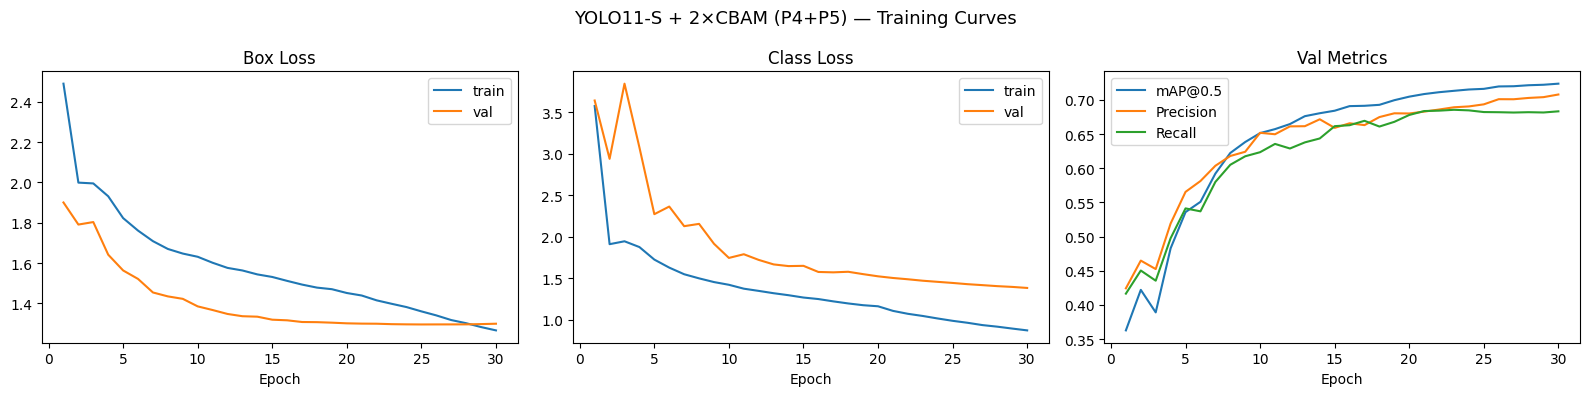

In [16]:
RUN_DIR = "/kaggle/working/runs/yolo11s_2cbam_p4p5"
BEST_PT = f"{RUN_DIR}/weights/best.pt"

df = pd.read_csv(f"{RUN_DIR}/results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + 2×CBAM (P4+P5) — Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/yolo11s_2cbam_p4p5_curves.png", dpi=120)
plt.show()

---
## 13. Evaluation — Eval A / B / C

In [17]:
try:
    del cbam_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)
lbl_test   = Path(f"{UNIFIED}/labels/test")
img_test   = Path(f"{UNIFIED}/images/test")
lbl_val    = Path(f"{UNIFIED}/labels/val")
img_val    = Path(f"{UNIFIED}/images/val")

def batched_fp_rate(model, hard_neg_imgs, batch_size=200):
    fp = 0
    for i in range(0, len(hard_neg_imgs), batch_size):
        preds = model.predict(source=hard_neg_imgs[i:i+batch_size],
                              imgsz=640, conf=0.25, device=0, verbose=False)
        fp += sum(1 for r in preds if len(r.boxes) > 0)
        torch.cuda.empty_cache()
    return fp, fp / len(hard_neg_imgs) if hard_neg_imgs else 0

def get_hard_negs(img_dir, lbl_dir):
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in lbl_dir.glob("*.txt")
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

VRAM free: 15.4 GB ✅


In [18]:
print("── EVAL A: D-Fire Test Set ────────────────────────────────────")
metrics_A = eval_model.val(
    data="/kaggle/working/data.yaml", split="test",
    imgsz=640, batch=8, device=0,
    plots=True, project=RUN_DIR, name="eval_A_dfire_test", exist_ok=True,
)
map50_A, map5095_A = metrics_A.box.map50, metrics_A.box.map
prec_A,  rec_A     = metrics_A.box.mp,    metrics_A.box.mr
fp_A, fp_rate_A    = batched_fp_rate(eval_model, get_hard_negs(img_test, lbl_test))
print(f"  mAP@0.5 : {map50_A:.4f} | Recall : {rec_A:.4f} | FP Rate : {fp_rate_A:.4f}")
for i, cls in enumerate(["smoke","fire"]):
    print(f"  AP50 {cls:6s}: {metrics_A.box.ap50[i]:.4f}")

── EVAL A: D-Fire Test Set ────────────────────────────────────
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_2cbam_p4p5 summary (fused): 117 layers, 9,454,730 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12.8±9.6 MB/s, size: 102.6 KB)
val: Scanning /kaggle/working/unified_dataset/labels/test... 3754 images, 2005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3754/3754 731.2it/s 5.1s
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11243.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11244.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11245.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11313.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11315.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unifi

In [19]:
print("── EVAL B: Combined Val Set ───────────────────────────────────")
torch.cuda.empty_cache()
metrics_B = eval_model.val(
    data="/kaggle/working/data.yaml", split="val",
    imgsz=640, batch=8, device=0,
    plots=True, project=RUN_DIR, name="eval_B_combined_val", exist_ok=True,
)
map50_B, map5095_B = metrics_B.box.map50, metrics_B.box.map
prec_B,  rec_B     = metrics_B.box.mp,    metrics_B.box.mr
fp_B, fp_rate_B    = batched_fp_rate(eval_model, get_hard_negs(img_val, lbl_val))
print(f"  mAP@0.5 : {map50_B:.4f} | Recall : {rec_B:.4f} | FP Rate : {fp_rate_B:.4f}")

── EVAL B: Combined Val Set ───────────────────────────────────
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1612.1±1015.8 MB/s, size: 187.1 KB)
val: Scanning /kaggle/working/unified_dataset/labels/val.cache... 7025 images, 2129 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7025/7025 1.5Git/s 0.0s
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07536.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07539.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07561.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 879/879 13.2it/s 1:07
                   all       7025       7079      0.711      0.681      0.724      0.413
                 smoke       4733       5668      0.699      0.721      0.734      0.442
         

In [20]:
print("── EVAL C: PyroNear Val (tower cameras) ───────────────────────")
pyro_val_imgs = sorted(img_val.glob("pyro_*.jpg"))
pyro_val_lbls = [lbl_val / p.with_suffix(".txt").name for p in pyro_val_imgs]
pyro_pos      = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
pyro_neg      = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())
print(f"  Positives: {pyro_pos} | Hard negatives: {pyro_neg}")

tp_C = fp_C = fn_C = 0
for i in range(0, len(pyro_val_imgs), 200):
    chunk_imgs = [str(p) for p in pyro_val_imgs[i:i+200]]
    chunk_lbls = pyro_val_lbls[i:i+200]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_C += 1
        elif   has_gt and not has_det: fn_C += 1
        elif not has_gt and   has_det: fp_C += 1
    torch.cuda.empty_cache()

fp_rate_C = fp_C / pyro_neg if pyro_neg else 0
recall_C  = tp_C / pyro_pos if pyro_pos else 0
print(f"  TP: {tp_C} | FP: {fp_C} | FN: {fn_C}")
print(f"  FP Rate: {fp_rate_C:.4f} ({fp_rate_C*100:.1f}%) | Recall: {recall_C:.4f} ({recall_C*100:.1f}%)")

── EVAL C: PyroNear Val (tower cameras) ───────────────────────
  Positives: 3345 | Hard negatives: 754
  TP: 3007 | FP: 427 | FN: 338
  FP Rate: 0.5663 (56.6%) | Recall: 0.8990 (89.9%)


---
## 14. Results Summary & Save

In [21]:
print("\n" + "="*65)
print(" RESULTS — YOLO11-S + 2×CBAM (P4+P5)")
print("="*65)
print(f"  {'Eval':<38} {'mAP@0.5':>8} {'Prec':>8} {'Rec':>8} {'FP Rate':>8}")
print(f"  {'-'*65}")
print(f"  {'A: D-Fire test  (cross-dataset)':<38} {map50_A:>8.4f} {prec_A:>8.4f} {rec_A:>8.4f} {fp_rate_A:>8.4f}")
print(f"  {'B: Combined val (all datasets)':<38} {map50_B:>8.4f} {prec_B:>8.4f} {rec_B:>8.4f} {fp_rate_B:>8.4f}")
print(f"  {'C: PyroNear val (tower only)':<38} {'—':>8} {'—':>8} {recall_C:>8.4f} {fp_rate_C:>8.4f}")
print("="*65)

print("\n── Ablation Table Context ──────────────────────────────────────────────")
ablation = [
    ("Baseline",             0.7653, 0.6835, 1.70, 0.7344, 0.8852, 0.6074),
    ("1×CBAM SPPF",          0.7550, 0.6736, 2.19, 0.7308, 0.9046, 0.6008),
    ("3×CBAM Neck",          0.7409, 0.6708, 1.20, 0.7200, 0.8251, 0.4231),
    ("4×CBAM (SPPF+3×Neck)", 0.7574, 0.6873, 2.19, 0.7328, 0.9136, 0.5889),
    ("2×CBAM (SPPF+P4)",     0.7655, 0.6931, 1.85, 0.7306, 0.8957, 0.5915),
    ("AG Skips (#2)",        0.7515, 0.6804, 1.05, 0.7236, 0.8921, 0.5623),
    ("CA+CBAM (#4)",         0.7583, 0.6895, 1.75, 0.7310, 0.9157, 0.6154),
    ("DCT (#3)",             0.7652, 0.6853, 1.75, 0.7333, 0.9133, 0.6167),
    ("DCT+AG",               0.7470, 0.6713, 1.90, 0.7250, 0.9205, 0.5849),
    ("DCT+AG+3×Neck",        0.7489, 0.6858, 2.04, 0.7203, 0.8873, 0.5875),
]
print(f"  {'Config':<28} {'mAP-D':>7} {'Rec-D':>7} {'FP-D':>6} {'mAP-C':>7} {'Rec-P':>7} {'FP-P':>6}")
print(f"  {'-'*68}")
for row in ablation:
    name, ma, rc, fp, mc, rp, fpp = row
    print(f"  {name:<28} {ma:>7.4f} {rc:>7.4f} {fp:>5.1f}% {mc:>7.4f} {rp:>7.4f} {fpp*100:>5.1f}%")
print(f"  {'─'*68}")
print(f"  {'2×CBAM P4+P5 (THIS RUN)':<28} {map50_A:>7.4f} {rec_A:>7.4f} {fp_rate_A*100:>5.1f}% {map50_B:>7.4f} {recall_C:>7.4f} {fp_rate_C*100:>5.1f}%")

results = {
    "model"                   : "YOLO11-S + 2×CBAM (P4+P5)",
    "train_data"              : "unified (55,698)",
    "params"                  : "~9.4M + CBAM×2",
    "mAP50_dfire_test"        : round(float(map50_A),    4),
    "mAP5095_dfire_test"      : round(float(map5095_A),  4),
    "precision_dfire_test"    : round(float(prec_A),     4),
    "recall_dfire_test"       : round(float(rec_A),      4),
    "fp_rate_dfire_test"      : round(float(fp_rate_A),  4),
    "ap50_smoke_dfire"        : round(float(metrics_A.box.ap50[0]), 4),
    "ap50_fire_dfire"         : round(float(metrics_A.box.ap50[1]), 4),
    "mAP50_combined_val"      : round(float(map50_B),    4),
    "mAP5095_combined_val"    : round(float(map5095_B),  4),
    "precision_combined_val"  : round(float(prec_B),     4),
    "recall_combined_val"     : round(float(rec_B),      4),
    "fp_rate_combined_val"    : round(float(fp_rate_B),  4),
    "ap50_smoke_combined"     : round(float(metrics_B.box.ap50[0]), 4),
    "ap50_fire_combined"      : round(float(metrics_B.box.ap50[1]), 4),
    "recall_pyronear_val"     : round(float(recall_C),   4),
    "fp_rate_pyronear_val"    : round(float(fp_rate_C),  4),
    "tp_pyronear"             : int(tp_C),
    "fp_pyronear"             : int(fp_C),
    "fn_pyronear"             : int(fn_C),
}

results_csv = "/kaggle/working/yolo11s_2cbam_p4p5_results.csv"
pd.DataFrame([results]).to_csv(results_csv, index=False)
print(f"\nResults saved → {results_csv} ✅")


 RESULTS — YOLO11-S + 2×CBAM (P4+P5)
  Eval                                    mAP@0.5     Prec      Rec  FP Rate
  -----------------------------------------------------------------
  A: D-Fire test  (cross-dataset)          0.7454   0.7573   0.6684   0.0170
  B: Combined val (all datasets)           0.7242   0.7108   0.6808   0.2137
  C: PyroNear val (tower only)                  —        —   0.8990   0.5663

── Ablation Table Context ──────────────────────────────────────────────
  Config                         mAP-D   Rec-D   FP-D   mAP-C   Rec-P   FP-P
  --------------------------------------------------------------------
  Baseline                      0.7653  0.6835   1.7%  0.7344  0.8852  60.7%
  1×CBAM SPPF                   0.7550  0.6736   2.2%  0.7308  0.9046  60.1%
  3×CBAM Neck                   0.7409  0.6708   1.2%  0.7200  0.8251  42.3%
  4×CBAM (SPPF+3×Neck)          0.7574  0.6873   2.2%  0.7328  0.9136  58.9%
  2×CBAM (SPPF+P4)              0.7655  0.6931   1.9%  0

In [22]:
shutil.make_archive("/kaggle/working/yolo11s_2cbam_p4p5_full", "zip",
                    "/kaggle/working/runs/yolo11s_2cbam_p4p5")
print("Full run directory zipped → yolo11s_2cbam_p4p5_full.zip ✅")

Full run directory zipped → yolo11s_2cbam_p4p5_full.zip ✅


In [23]:
import shutil
import os

print("── Starting Final Cleanup ──────────────────────────")
directories_to_delete = [
    "/kaggle/working/unified_dataset",
    "/kaggle/working/pyro_yolo",
    "/kaggle/working/nemo_yolo"
]

for dir_path in directories_to_delete:
    if os.path.exists(dir_path):
        print(f"Deleting {dir_path}...")
        shutil.rmtree(dir_path)

print("Cleanup complete! Your Kaggle output will be lightweight. ✅")

── Starting Final Cleanup ──────────────────────────
Deleting /kaggle/working/unified_dataset...
Deleting /kaggle/working/pyro_yolo...
Deleting /kaggle/working/nemo_yolo...
Cleanup complete! Your Kaggle output will be lightweight. ✅
